# Batch Processing

If the number of frames (files) to process exceeds the defined `batch_size` (default: 32),
the `Batch()` mode is activated automatically.

At the initialization step (`analysis = pygid.Conversion(...)`), **images are not loaded into memory**.
When conversion functions (`det2q_gid`, `det2pol_gid`, etc.) are called, the raw data paths are
split into batches and processed sequentially.

In batch mode:

- Converted images **are not plotted**.
- Results **cannot be returned** directly to the workspace, except when `average_all=True`
  or `sum_all=True`.
- Only **saving to disk** is supported, except for the averaged or summed result when
  `average_all=True` or `sum_all=True`.

#### Parameters

- `batch_size` – maximum number of frames or files processed per batch. Default: `32`.
- `multiprocessing` – enables multiprocessing for faster batch execution.
- `plot_result` – must be `False` (plotting is disabled in batch mode).
- `save_result` – must be `True` to store converted data in HDF5/NXsas format.
- `path_to_save` – path where converted data will be saved.
- `overwrite_file` – whether to overwrite an existing result file.

#### Example

In the example below, `batch_size` is set to `2` to explicitly activate batch processing. Total number of frames in the raw data file: 13.


In [19]:
from pygid.datasets import get_dataset

# Download example dataset from Zenodo
files = get_dataset("tutorial_07")
poni_path = files["poni"]
mask_path = files["mask"]
# several files for batch processing
data_path = files["data"]

In [20]:
import pygid

params = pygid.ExpParams(
    poni_path=poni_path,
    mask_path=mask_path,
    ai=0.004,
    fliplr=True,
    flipud=True
)

matrix = pygid.CoordMaps(
    params,
    vert_positive=True,
    hor_positive=True,
)

analysis = pygid.Conversion(
    matrix=matrix,
    path=data_path,
    dataset='/entry_0000/ESRF-ID10/eiger4m/data',
    frame_num = None,             # all image
    batch_size=2,                 # limit of the batch size
)
print(f"loaded images: {analysis.img_raw}")

INFO - Number of frames (13) is more than 2. The batch processing has been activated.


loaded images: None


NOTE: images are not loaded

In [21]:
analysis.det2q_gid(save_result=True,
                   path_to_save='result.h5')

Progress:   0%|          | 0/7 [00:00<?, ?it/s]

INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000


In [22]:
analysis.det2q_gid(save_result=True,
                   path_to_save='result.h5',
                   plot_result=True)

Progress:   0%|          | 0/7 [00:00<?, ?it/s]

INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000
D:\PhD\mlgid\pygid\pygid\conversion.py:304: UserWarning: Plotting and returning of the result are not supported in batch analysis mode.
  warnings.warn("Plotting and returning of the result are not supported in batch analysis mode.",


NOTE: plotting is not supported

The Batch processing works for all two-dimensional conversions and radial profiles (see Tutorials 4-5):

In [ ]:
analysis.radial_profile_gid(save_result=True,
                   path_to_save='result.h5',
                   plot_result=True)

### In combination with averaging:

INFO - Number of frames (13) is more than 2. The batch processing has been activated.


Progress:   0%|          | 0/7 [00:00<?, ?it/s]

INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000


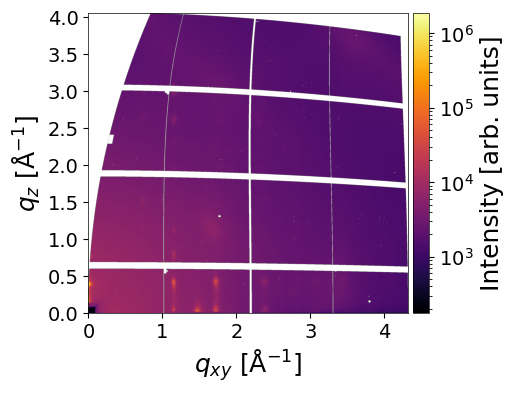

In [23]:
analysis = pygid.Conversion(
    matrix=matrix,
    path=data_path,
    dataset='/entry_0000/ESRF-ID10/eiger4m/data',
    frame_num = None,             # all image
    batch_size=2,                 # limit of the batch size
    average_all=True,             # average all frames
)
analysis.det2q_gid(save_result=True,
                   path_to_save='result.h5',
                   plot_result=True)